# Convert SmartSolo MiniSEED to SDS using `EnhancedSDSClient`

This notebook rebuilds the Karst Geophysics SmartSolo nodal SDS archive from the SoloLite MiniSEED exports.

The important change relative to the first version is that we **do not manually construct SDS filenames or write day files ourselves**. Instead, we use:

```python
EnhancedSDSClient.write_stream(..., mode="merge")
```

This matters because many SmartSolo files span UTC midnight. The enhanced writer:

1. splits traces at UTC day boundaries;
2. groups traces by SDS dayfile;
3. appends/merges with existing SDS files;
4. writes atomically.

The metadata convention used here is:

| Item | Convention |
|---|---|
| Network | `T1` for Transect1, `T3` for TransectE |
| Location | `N1`, `N2`, `N3`, `N4` for nodal deployments |
| Station | preserve SmartSolo station code, e.g. `05726` |
| Channel | preserve SmartSolo channel code, e.g. `DPE/DPN/DPZ` or `GPE/GPN/GPZ` |

So a typical output trace ID is:

```text
T1.05726.N2.DPZ
```


In [1]:
from __future__ import annotations

from collections import Counter
from pathlib import Path
import re
import shutil
import time

import pandas as pd
from obspy import read, Stream, UTCDateTime

from flovopy.enhanced.sdsclient import EnhancedSDSClient


## 1. Configuration

Edit these paths if needed. The `deployments` dictionary maps each SoloLite export folder to the network and location code to assign.

Set `DRY_RUN = True` for a quick metadata check without writing SDS files.


In [2]:
BASE = Path("/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics")
SDS_ROOT = Path("/Volumes/tachyon/LBSSP_DATA/nodal_sds")

# If True, do not write anything. Useful for checking file discovery and metadata.
DRY_RUN = False

# If True, move the existing SDS archive aside before rebuilding.
# This is recommended when replacing the old manually-written archive.
MOVE_EXISTING_ARCHIVE_ASIDE = False

# Optional limit for testing. Use None for all files.
LIMIT_FILES_PER_DEPLOYMENT = None

# Write in batches to reduce repeated reads/rewrites of SDS dayfiles.
# Larger is faster but uses more memory. 25--100 is reasonable for these 24-hour files.
BATCH_SIZE = 25

# Verbosity passed to EnhancedSDSClient.write_stream().
WRITE_VERBOSE = False

# SoloLite export folders and the network/location codes to assign.
deployments = {
    "Transect1_Nodal1_500Hz":  ("T1", "N1"),
    "Transect1_Nodal2_500Hz":  ("T1", "N2"),
    "Transect1_Nodal3_500Hz":  ("T1", "N3"),
    "TransectE_Nodal4_500Hz":  ("T3", "N4"),
    "Transect1_Nodal1_1000Hz": ("T1", "N1"),
    "Transect1_Nodal2_1000Hz": ("T1", "N2"),
    "Transect1_Nodal3_1000Hz": ("T1", "N3"),
    "TransectE_Nodal4_1000Hz": ("T3", "N4"),
}

# SmartSolo/SoloLite filenames, e.g.
# 453005726.0001.2026.05.17.16.00.00.000.Z.miniseed
filename_pattern = re.compile(
    r"(?P<serial>\d+)\.(?P<fileno>\d+)\."
    r"(?P<year>\d{4})\.(?P<month>\d{2})\.(?P<day>\d{2})\."
    r"(?P<hour>\d{2})\.(?P<minute>\d{2})\.(?P<second>\d{2})\."
    r"(?P<msec>\d{3})\.(?P<comp>[ENZ])\."
    r"(?P<ext>miniseed|sac)$",
    re.IGNORECASE,
)


## 2. Optional: move old SDS archive aside

Do this before rebuilding if the old SDS archive was created by manually writing dayfiles. That older approach did not split traces across UTC day boundaries and caused missing hours after midnight.


In [3]:
if MOVE_EXISTING_ARCHIVE_ASIDE and SDS_ROOT.exists():
    timestamp = time.strftime("%Y%m%d_%H%M%S")
    backup = SDS_ROOT.with_name(f"{SDS_ROOT.name}_old_{timestamp}")
    print("Moving existing SDS archive:")
    print(f"  {SDS_ROOT}")
    print("to:")
    print(f"  {backup}")
    shutil.move(str(SDS_ROOT), str(backup))

SDS_ROOT.mkdir(parents=True, exist_ok=True)
print(f"SDS root: {SDS_ROOT}")


SDS root: /Volumes/tachyon/LBSSP_DATA/nodal_sds


## 3. Discover source files

This cell checks which deployment folders exist and how many MiniSEED files each contains.


In [4]:
deployment_files = {}

for folder, (net, loc) in deployments.items():
    src = BASE / folder
    print(f"Discovering files in {src}...")
    if folder=='TransectE_Nodal4_500Hz':
        ext = 'sac'
    else:
        ext = 'miniseed'
    files = sorted(src.glob(f"*.{ext}")) if src.exists() else []
    if LIMIT_FILES_PER_DEPLOYMENT is not None:
        files = files[:LIMIT_FILES_PER_DEPLOYMENT]
    deployment_files[folder] = files

summary = []
for folder, files in deployment_files.items():
    net, loc = deployments[folder]
    summary.append({
        "folder": folder,
        "network": net,
        "location": loc,
        "exists": (BASE / folder).exists(),
        "n_miniseed_files": len(files),
    })

pd.DataFrame(summary)


Discovering files in /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal1_500Hz...
Discovering files in /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal2_500Hz...
Discovering files in /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal3_500Hz...
Discovering files in /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/TransectE_Nodal4_500Hz...
Discovering files in /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal1_1000Hz...
Discovering files in /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal2_1000Hz...
Discovering files in /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal3_1000Hz...
Discovering files in /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/TransectE_Nodal4_1000Hz...


,folder,network,location,exists,n_miniseed_files
0,Transect1_Nodal1_500Hz,T1,N1,True,162
1,Transect1_Nodal2_500Hz,T1,N2,True,165
2,Transect1_Nodal3_500Hz,T1,N3,True,93
3,TransectE_Nodal4_500Hz,T3,N4,True,183
4,Transect1_Nodal1_1000Hz,T1,N1,True,72
5,Transect1_Nodal2_1000Hz,T1,N2,True,72
6,Transect1_Nodal3_1000Hz,T1,N3,True,36
7,TransectE_Nodal4_1000Hz,T3,N4,True,36


## 4. Inspect sample files

This confirms that SoloLite already put the desired 5-digit station code and `DP*`/`GP*` channel codes into the MiniSEED headers. The conversion below preserves these and only changes network/location.


In [5]:
def inspect_first_files(deployment_files, n_per_deployment=1):
    rows = []
    for folder, files in deployment_files.items():
        net, loc = deployments[folder]
        for f in files[:n_per_deployment]:
            try:
                st = read(str(f), headonly=True)
            except Exception as exc:
                rows.append({"folder": folder, "file": f.name, "error": str(exc)})
                continue
            for tr in st:
                rows.append({
                    "folder": folder,
                    "target_network": net,
                    "target_location": loc,
                    "file": f.name,
                    "original_id": tr.id,
                    "station": tr.stats.station,
                    "location": tr.stats.location,
                    "channel": tr.stats.channel,
                    "sampling_rate": tr.stats.sampling_rate,
                    "starttime": str(tr.stats.starttime),
                    "endtime": str(tr.stats.endtime),
                    "npts": tr.stats.npts,
                })
    return pd.DataFrame(rows)

inspect_df = inspect_first_files(deployment_files, n_per_deployment=1)
inspect_df


,folder,target_network,target_location,file,original_id,station,location,channel,sampling_rate,starttime,endtime,npts
0,Transect1_Nodal1_500Hz,T1,N1,453005726.0001.2026.05.16.17.28.34.000.E.miniseed,SS.05726.SW.DPE,05726,SW,DPE,500.000000,2026-05-16T17:28:34.000000Z,2026-05-17T00:00:00.000000Z,11743001
1,Transect1_Nodal2_500Hz,T1,N2,453005726.0001.2026.05.17.16.00.00.000.E.miniseed,SS.05726.SW.DPE,05726,SW,DPE,500.000000,2026-05-17T16:00:00.000000Z,2026-05-18T16:00:00.000000Z,43200001
2,Transect1_Nodal3_500Hz,T1,N3,453005726.0001.2026.05.19.13.20.00.000.E.miniseed,SS.05726.SW.DPE,05726,SW,DPE,500.000000,2026-05-19T13:20:00.000000Z,2026-05-19T14:20:58.000000Z,1829001
3,TransectE_Nodal4_500Hz,T3,N4,453005726.0001.2026.05.19.15.21.56.000.E.sac,.3005726..DPE,3005726,,DPE,499.999969,2026-05-19T15:21:56.000000Z,2026-05-19T18:25:00.000670Z,5492001
4,Transect1_Nodal1_1000Hz,T1,N1,453005764.0001.2026.05.16.16.09.03.000.E.miniseed,SS.05764.SW.GPE,05764,SW,GPE,1000.000000,2026-05-16T16:09:03.000000Z,2026-05-17T00:00:00.000000Z,28257001
5,Transect1_Nodal2_1000Hz,T1,N2,453005764.0001.2026.05.17.16.00.00.000.E.miniseed,SS.05764.SW.GPE,05764,SW,GPE,1000.000000,2026-05-17T16:00:00.000000Z,2026-05-18T16:00:00.000000Z,86400001
6,Transect1_Nodal3_1000Hz,T1,N3,453005764.0001.2026.05.19.13.20.00.000.E.miniseed,SS.05764.SW.GPE,05764,SW,GPE,1000.000000,2026-05-19T13:20:00.000000Z,2026-05-19T14:24:13.000000Z,3853001
7,TransectE_Nodal4_1000Hz,T3,N4,453005764.0001.2026.05.19.15.22.06.000.E.miniseed,SS.05764.SW.GPE,05764,SW,GPE,1000.000000,2026-05-19T15:22:06.000000Z,2026-05-19T18:25:00.000000Z,10974001


## 5. Conversion helpers

The key function is `read_and_recode_file()`: it reads one SoloLite MiniSEED file, preserves station/channel, and changes only network/location.

The actual SDS writing is handled by `EnhancedSDSClient.write_stream()`, which is responsible for splitting across days and merging with existing dayfiles.


In [6]:
def read_and_recode_file(path: Path, network: str, location: str) -> Stream:
    """Read one MiniSEED file and assign target network/location codes."""
    st = read(str(path))

    m = filename_pattern.match(path.name)
    serial_suffix = None
    if m:
        serial_suffix = m.group("serial")[-5:]

    for tr in st:
        original_id = tr.id

        # Preserve SmartSolo station and channel codes.
        # Only assign project network and deployment/location code.
        tr.stats.network = network
        tr.stats.location = location

        # Sanity check: SmartSolo station should already be the serial suffix.
        # Do not change it unless you explicitly decide to.
        if serial_suffix:
            if tr.stats.station != serial_suffix:
                print(
                    f"Correcting station for {path.name}: "
                    f"header station={tr.stats.station}, filename suffix={serial_suffix}"
                )
            tr.stats.station = serial_suffix

    return st


def flush_batch_to_sds(client: EnhancedSDSClient, batch: Stream, *, dry_run: bool = False) -> list[Path]:
    """Write a batch Stream to SDS using the robust EnhancedSDSClient writer."""
    if len(batch) == 0:
        return []

    if dry_run:
        print(f"DRY RUN: would write {len(batch)} traces")
        for tr in batch[:5]:
            print(f"  {tr.id} {tr.stats.starttime} {tr.stats.endtime} sr={tr.stats.sampling_rate}")
        if len(batch) > 5:
            print(f"  ... {len(batch) - 5} more traces")
        return []

    # Important: preprocess=False preserves the SoloLite-exported sample values
    # and avoids unintended resampling/harmonization. write_stream still splits
    # at UTC day boundaries and, in mode='merge', merges with existing SDS files.
    return client.write_stream(
        batch,
        mode="merge",
        preprocess=False,
        verbose=WRITE_VERBOSE,
    )


## 6. Build the SDS archive

This loops over all deployment folders, reads MiniSEED files, rewrites network/location, accumulates a batch, and writes via the enhanced SDS writer.

If this is your first full rebuild, set `MOVE_EXISTING_ARCHIVE_ASIDE = True` above before running the notebook from the top.


In [7]:
client = EnhancedSDSClient(SDS_ROOT)

conversion_rows = []
all_written_paths = []

for folder, files in deployment_files.items():
    network, location = deployments[folder]
    src = BASE / folder

    if not src.exists():
        print(f"Missing folder, skipping: {src}")
        continue

    print("\n" + "=" * 100)
    print(f"Processing {folder}")
    print(f"  source:   {src}")
    print(f"  network:  {network}")
    print(f"  location: {location}")
    print(f"  files:    {len(files)}")

    batch = Stream()
    n_read = 0
    n_failed = 0
    n_written_batches = 0

    for i, f in enumerate(files, start=1):
        if not filename_pattern.match(f.name):
            print(f"  Skipping non-matching filename: {f.name}")
            continue

        try:
            st = read_and_recode_file(f, network, location)
        except Exception as exc:
            n_failed += 1
            print(f"  Could not read {f.name}: {exc}")
            continue

        n_read += 1
        batch += st

        if len(batch) >= BATCH_SIZE or i == len(files):
            written = flush_batch_to_sds(client, batch, dry_run=DRY_RUN)
            all_written_paths.extend(written)
            n_written_batches += 1
            print(
                f"  batch {n_written_batches}: files_read={n_read}, "
                f"batch_traces={len(batch)}, written_files={len(written)}"
            )
            batch = Stream()

    conversion_rows.append({
        "folder": folder,
        "source": str(src),
        "network": network,
        "location": location,
        "n_files": len(files),
        "n_files_read": n_read,
        "n_files_failed": n_failed,
        "n_batches_written": n_written_batches,
    })

conversion_summary = pd.DataFrame(conversion_rows)
conversion_summary



Processing Transect1_Nodal1_500Hz
  source:   /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal1_500Hz
  network:  T1
  location: N1
  files:    162
  batch 1: files_read=25, batch_traces=25, written_files=25
  batch 2: files_read=50, batch_traces=25, written_files=25
  batch 3: files_read=75, batch_traces=25, written_files=22
  batch 4: files_read=100, batch_traces=25, written_files=25
  batch 5: files_read=125, batch_traces=25, written_files=22
  batch 6: files_read=150, batch_traces=25, written_files=18
  batch 7: files_read=162, batch_traces=12, written_files=9

Processing Transect1_Nodal2_500Hz
  source:   /Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_geokarst/Karst_Geophysics/Transect1_Nodal2_500Hz
  network:  T1
  location: N2
  files:    165
  batch 1: files_read=25, batch_traces=25, written_files=37
  batch 2: files_read=50, batch_traces=25, written_files=35
  batch 3: files_read=75, batch_traces=25, written_files=35
  batch 4: files_read

,folder,source,network,location,n_files,n_files_read,n_files_failed,n_batches_written
0,Transect1_Nodal1_500Hz,/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_...,T1,N1,162,162,0,7
1,Transect1_Nodal2_500Hz,/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_...,T1,N2,165,165,0,7
2,Transect1_Nodal3_500Hz,/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_...,T1,N3,93,93,0,4
3,TransectE_Nodal4_500Hz,/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_...,T3,N4,183,183,0,8
4,Transect1_Nodal1_1000Hz,/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_...,T1,N1,72,72,0,3
5,Transect1_Nodal2_1000Hz,/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_...,T1,N2,72,72,0,3
6,Transect1_Nodal3_1000Hz,/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_...,T1,N3,36,36,0,2
7,TransectE_Nodal4_1000Hz,/Volumes/tachyon/LBSSP_DATA/SOLODATA/prospect_...,T3,N4,36,36,0,2


## 7. Written SDS paths summary

The same SDS dayfile can be rewritten several times during merge mode, especially if batches contribute to the same day. This summary counts unique paths touched.


In [8]:
written_counter = Counter(str(p) for p in all_written_paths)
written_summary = pd.DataFrame(
    [{"sds_file": path, "write_count": count} for path, count in sorted(written_counter.items())]
)
print(f"Total write operations: {len(all_written_paths)}")
print(f"Unique SDS files touched: {len(written_summary)}")
written_summary.head(20)


Total write operations: 781
Unique SDS files touched: 750


,sds_file,write_count
0,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
1,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
2,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
3,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
4,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
5,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
6,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
7,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
8,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1
9,/Volumes/tachyon/LBSSP_DATA/nodal_sds/2026/T1/...,1


## 8. Quick read-back sanity checks

These examples should return continuous data across midnight if the SDS archive was written correctly.

Edit the examples if a particular station/location/channel is more relevant.


In [17]:
# Example read across a previously problematic period.
# This should work if T1/N1/DPZ data exist for station 05726.
try:
    st_check = client.get_waveforms(
        network="T1",
        station="05726",
        location="N1",
        channel="DPZ",
        starttime=UTCDateTime("2026-05-17T00:00:00"),
        endtime=UTCDateTime("2026-05-17T16:00:00"),
    )
    print(st_check)
except Exception as exc:
    print(f"Read-back check failed: {exc}")


1 Trace(s) in Stream:
T1.05726.N1.DPZ | 2026-05-17T00:00:00.000000Z - 2026-05-17T16:00:00.000000Z | 500.0 Hz, 28800001 samples


## 9. Discover trace IDs in the rebuilt SDS archive

This uses `EnhancedSDSClient.iter_trace_ids()`.


In [10]:
start = UTCDateTime("2026-05-16")
end = UTCDateTime("2026-05-21")  # exclusive for daily availability

trace_ids = client.iter_trace_ids(start, end)
trace_ids = sorted(trace_ids)
print(f"Found {len(trace_ids)} trace IDs")
for tid in trace_ids[:50]:
    print(tid)
if len(trace_ids) > 50:
    print(f"... {len(trace_ids) - 50} more")


Found 432 trace IDs
T1.05726.N1.DPE
T1.05726.N1.DPN
T1.05726.N1.DPZ
T1.05726.N2.DPE
T1.05726.N2.DPN
T1.05726.N2.DPZ
T1.05726.N3.DPE
T1.05726.N3.DPN
T1.05726.N3.DPZ
T1.05764.N1.GPE
T1.05764.N1.GPN
T1.05764.N1.GPZ
T1.05764.N2.GPE
T1.05764.N2.GPN
T1.05764.N2.GPZ
T1.05764.N3.GPE
T1.05764.N3.GPN
T1.05764.N3.GPZ
T1.11708.N1.DPE
T1.11708.N1.DPN
T1.11708.N1.DPZ
T1.11708.N2.DPE
T1.11708.N2.DPN
T1.11708.N2.DPZ
T1.11708.N3.DPE
T1.11708.N3.DPN
T1.11708.N3.DPZ
T1.11953.N1.DPE
T1.11953.N1.DPN
T1.11953.N1.DPZ
T1.11953.N2.DPE
T1.11953.N2.DPN
T1.11953.N2.DPZ
T1.11953.N3.DPE
T1.11953.N3.DPN
T1.11953.N3.DPZ
T1.11986.N1.DPE
T1.11986.N1.DPN
T1.11986.N1.DPZ
T1.11986.N2.DPE
T1.11986.N2.DPN
T1.11986.N2.DPZ
T1.11986.N3.DPE
T1.11986.N3.DPN
T1.11986.N3.DPZ
T1.11990.N1.DPE
T1.11990.N1.DPN
T1.11990.N1.DPZ
T1.11990.N2.DPE
T1.11990.N2.DPN
... 382 more


## 10. Daily availability audit

This catches day-boundary problems immediately. Values should be fractions from 0 to 1 per UTC day.

The end day is exclusive, so `2026-05-21` includes May 16 through May 20.


In [11]:
availability_df, checked_trace_ids = client.get_availability(
    startday=start,
    endday=end,
    trace_ids=trace_ids,
    progress=True,
    verbose=False,
)

availability_df.head()


Availability: 100%|██████████| 5/5 [02:21<00:00, 28.24s/it]


,date,T1.05726.N1.DPE,T1.05726.N1.DPN,T1.05726.N1.DPZ,T1.05726.N2.DPE,T1.05726.N2.DPN,T1.05726.N2.DPZ,T1.05726.N3.DPE,T1.05726.N3.DPN,T1.05726.N3.DPZ,...,T3.19414.N4.GPZ,T3.20221.N4.DPE,T3.20221.N4.DPN,T3.20221.N4.DPZ,T3.20358.N4.DPE,T3.20358.N4.DPN,T3.20358.N4.DPZ,T3.20406.N4.GPE,T3.20406.N4.GPN,T3.20406.N4.GPZ
0,2026-05-16,0.271829,0.271829,0.271829,0.271829,0.271829,0.271829,0.271829,0.271829,0.271829,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2026-05-17,0.708333,0.708333,0.708333,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2026-05-18,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2026-05-19,0.597894,0.597894,0.597894,0.555556,0.555556,0.555556,0.042338,0.042338,0.042338,...,0.121007,0.128565,0.128565,0.128565,0.123588,0.123588,0.123588,0.128356,0.128356,0.128356
4,2026-05-20,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
# Save availability tables next to the SDS archive.
qc_dir = SDS_ROOT.parent / "nodal_qc"
qc_dir.mkdir(parents=True, exist_ok=True)

wide_csv = qc_dir / "rebuilt_sds_availability_wide.csv"
long_csv = qc_dir / "rebuilt_sds_availability_long.csv"
summary_csv = qc_dir / "rebuilt_sds_availability_summary.csv"

availability_df.to_csv(wide_csv, index=False)

long_df = availability_df.melt(
    id_vars=["date"],
    var_name="seed_id",
    value_name="availability",
)
long_df["availability_percent"] = 100.0 * long_df["availability"].astype(float)
parts = long_df["seed_id"].str.split(".", expand=True)
if parts.shape[1] == 4:
    long_df.insert(1, "network", parts[0])
    long_df.insert(2, "station", parts[1])
    long_df.insert(3, "location", parts[2])
    long_df.insert(4, "channel", parts[3])
long_df.to_csv(long_csv, index=False)

summary_df = (
    long_df.groupby("seed_id", as_index=False)
    .agg(
        n_days=("availability", "size"),
        n_days_with_data=("availability", lambda x: int((x > 0).sum())),
        mean_availability=("availability", "mean"),
        min_availability=("availability", "min"),
        max_availability=("availability", "max"),
    )
)
summary_df["mean_availability_percent"] = 100.0 * summary_df["mean_availability"]
summary_df["min_availability_percent"] = 100.0 * summary_df["min_availability"]
summary_df["max_availability_percent"] = 100.0 * summary_df["max_availability"]
summary_df.to_csv(summary_csv, index=False)

print(f"Wrote {wide_csv}")
print(f"Wrote {long_csv}")
print(f"Wrote {summary_csv}")
summary_df.head(20)


Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/rebuilt_sds_availability_wide.csv
Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/rebuilt_sds_availability_long.csv
Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/rebuilt_sds_availability_summary.csv


,seed_id,n_days,n_days_with_data,mean_availability,min_availability,max_availability,mean_availability_percent,min_availability_percent,max_availability_percent
0,T1.05726.N1.DPE,5,4,0.515611,0.0,1.0,51.561113,0.0,100.0
1,T1.05726.N1.DPN,5,4,0.515611,0.0,1.0,51.561113,0.0,100.0
2,T1.05726.N1.DPZ,5,4,0.515611,0.0,1.0,51.561113,0.0,100.0
3,T1.05726.N2.DPE,5,4,0.432144,0.0,1.0,43.214353,0.0,100.0
4,T1.05726.N2.DPN,5,4,0.432144,0.0,1.0,43.214353,0.0,100.0
5,T1.05726.N2.DPZ,5,4,0.432144,0.0,1.0,43.214353,0.0,100.0
6,T1.05726.N3.DPE,5,4,0.462833,0.0,1.0,46.283334,0.0,100.0
7,T1.05726.N3.DPN,5,4,0.462833,0.0,1.0,46.283334,0.0,100.0
8,T1.05726.N3.DPZ,5,4,0.462833,0.0,1.0,46.283334,0.0,100.0
9,T1.05764.N1.GPE,5,4,0.527106,0.0,1.0,52.710649,0.0,100.0


## 11. Per-deployment Z-component QC plots

These cells loop over each deployment defined in `deployments`, restrict the archive query to **Z-components only**, and write PNGs under:

```python
SDS_ROOT.parent / "nodal_qc"
```

For each deployment, the notebook writes:

- one full-deployment `Stream.plot()` PNG;
- one availability CSV;
- one availability heatmap PNG.

The waveform read can be memory-intensive for 500 Hz multi-day nodal data. The default below reads the full deployment time range, but you can narrow `QC_START` and `QC_END` if needed.



Z-component availability QC: network=T1, location=N1
  Z trace IDs: 36
    T1.05726.N1.DPZ
    T1.05764.N1.GPZ
    T1.11708.N1.DPZ
    T1.11953.N1.DPZ
    T1.11986.N1.DPZ
    T1.11990.N1.DPZ
    T1.12143.N1.DPZ
    T1.12150.N1.DPZ
    T1.12246.N1.DPZ
    T1.12320.N1.DPZ
    ... 26 more


Availability: 100%|██████████| 5/5 [00:22<00:00,  4.60s/it]


  Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N1_Z_availability.csv
Saved availability plot to /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N1_Z_availability_heatmap.png
  Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N1_Z_availability_heatmap.png

Z-component availability QC: network=T1, location=N2
  Z trace IDs: 36
    T1.05726.N2.DPZ
    T1.05764.N2.GPZ
    T1.11708.N2.DPZ
    T1.11953.N2.DPZ
    T1.11986.N2.DPZ
    T1.11990.N2.DPZ
    T1.12143.N2.DPZ
    T1.12150.N2.DPZ
    T1.12246.N2.DPZ
    T1.12320.N2.DPZ
    ... 26 more


Availability: 100%|██████████| 5/5 [00:22<00:00,  4.55s/it]


  Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N2_Z_availability.csv
Saved availability plot to /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N2_Z_availability_heatmap.png
  Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N2_Z_availability_heatmap.png

Z-component availability QC: network=T1, location=N3
  Z trace IDs: 36
    T1.05726.N3.DPZ
    T1.05764.N3.GPZ
    T1.11708.N3.DPZ
    T1.11953.N3.DPZ
    T1.11986.N3.DPZ
    T1.11990.N3.DPZ
    T1.12143.N3.DPZ
    T1.12150.N3.DPZ
    T1.12246.N3.DPZ
    T1.12320.N3.DPZ
    ... 26 more


Availability: 100%|██████████| 5/5 [00:22<00:00,  4.40s/it]


  Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N3_Z_availability.csv
Saved availability plot to /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N3_Z_availability_heatmap.png
  Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N3_Z_availability_heatmap.png

Z-component availability QC: network=T3, location=N1
  Z trace IDs: 0
  No matching Z trace IDs; skipping.

Z-component availability QC: network=T3, location=N2
  Z trace IDs: 0
  No matching Z trace IDs; skipping.

Z-component availability QC: network=T3, location=N3
  Z trace IDs: 0
  No matching Z trace IDs; skipping.

Wrote /Volumes/tachyon/LBSSP_DATA/nodal_qc/z_component_availability_qc_summary.csv


,network,location,start,end,n_z_trace_ids,n_checked_trace_ids,availability_csv,availability_heatmap_png
0,T1,N1,2026-05-16T00:00:00.000000Z,2026-05-21T00:00:00.000000Z,36,36.0,/Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N1_Z_a...,/Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N1_Z_a...
1,T1,N2,2026-05-16T00:00:00.000000Z,2026-05-21T00:00:00.000000Z,36,36.0,/Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N2_Z_a...,/Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N2_Z_a...
2,T1,N3,2026-05-16T00:00:00.000000Z,2026-05-21T00:00:00.000000Z,36,36.0,/Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N3_Z_a...,/Volumes/tachyon/LBSSP_DATA/nodal_qc/T1_N3_Z_a...
3,T3,N1,2026-05-16T00:00:00.000000Z,2026-05-21T00:00:00.000000Z,0,NaN,,
4,T3,N2,2026-05-16T00:00:00.000000Z,2026-05-21T00:00:00.000000Z,0,NaN,,
5,T3,N3,2026-05-16T00:00:00.000000Z,2026-05-21T00:00:00.000000Z,0,NaN,,


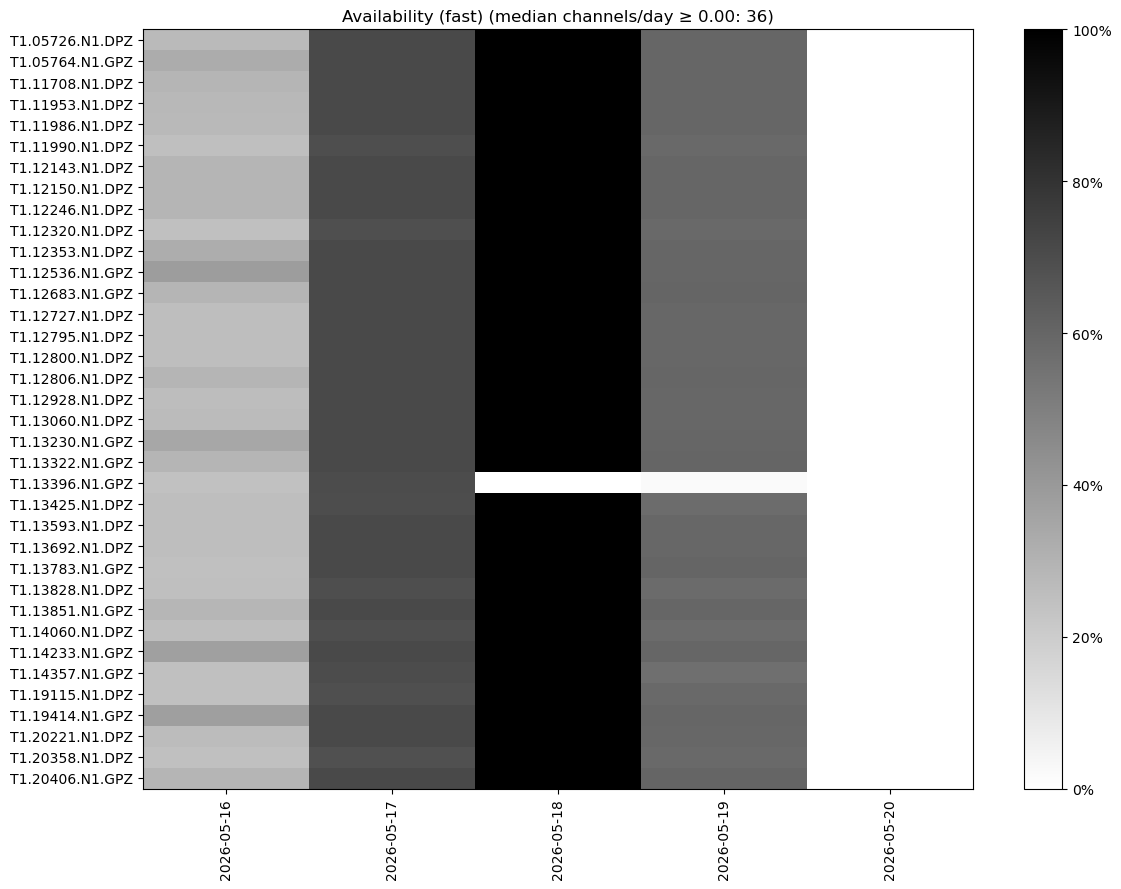

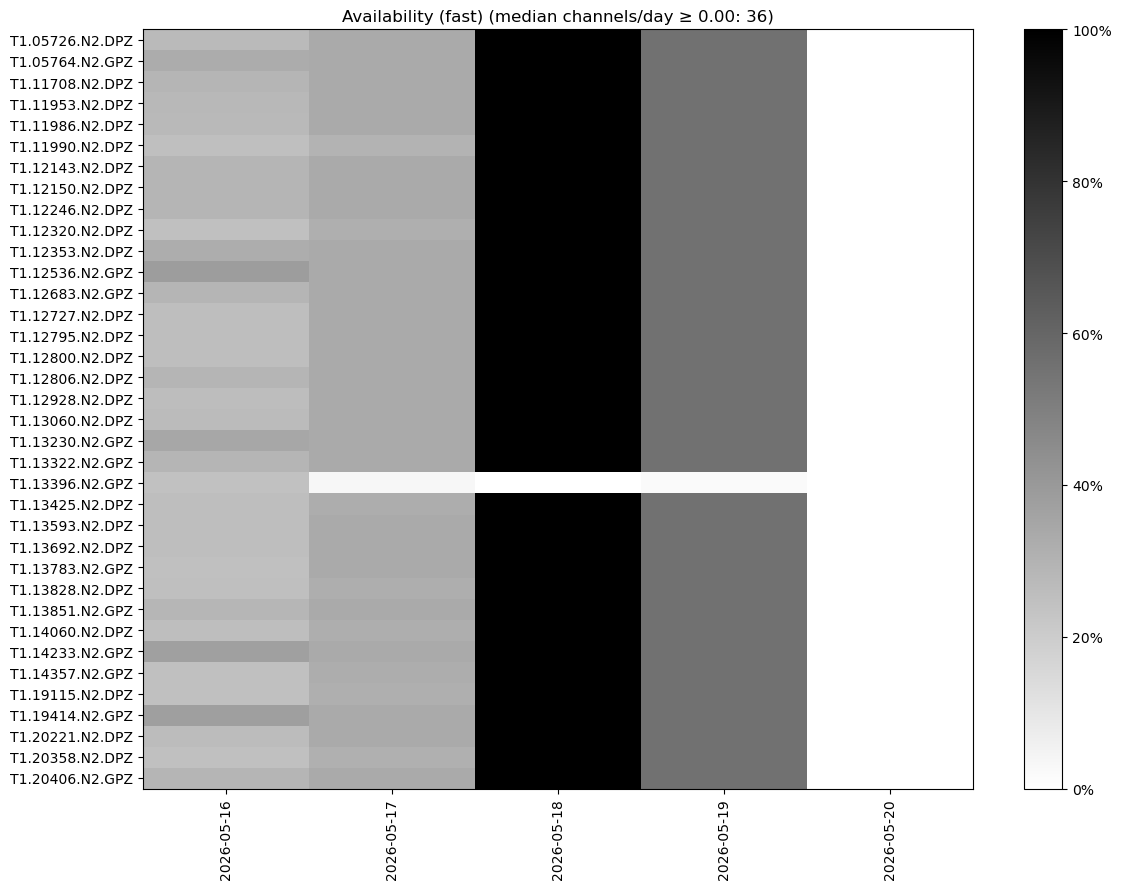

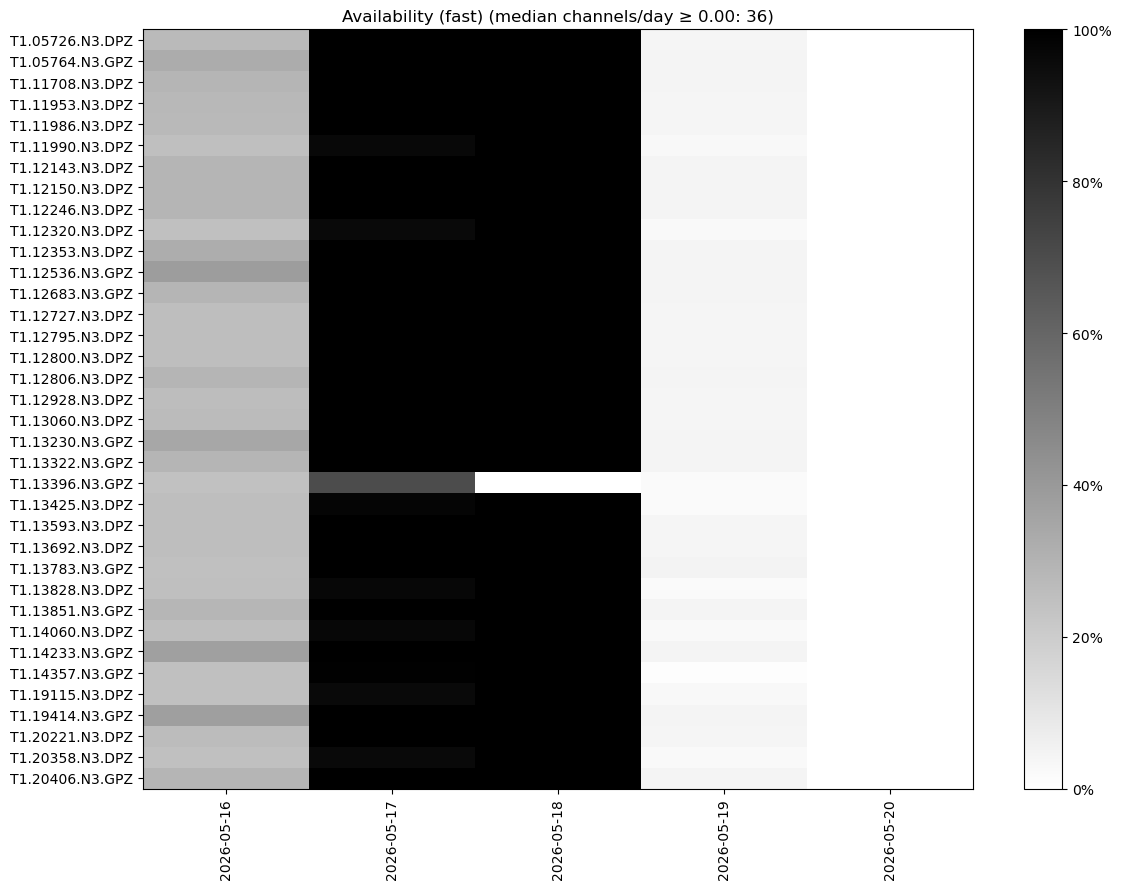

In [18]:
# Z-component availability QC only.
# One location/deployment at a time: N1, N2, N3.
# N4 can be added later once its metadata/SDS are ready.

qc_dir = SDS_ROOT.parent / "nodal_qc"
qc_dir.mkdir(parents=True, exist_ok=True)

QC_START = UTCDateTime("2026-05-16")
QC_END = UTCDateTime("2026-05-21")

NETWORKS = ["T1", "T3"]
LOCATIONS = ["N1", "N2", "N3"]

Z_CHANNEL_GLOB = "*Z"


def safe_name(text: str) -> str:
    """Return a filesystem-safe name."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")


def trace_id_parts(seed_id: str) -> tuple[str, str, str, str]:
    """Split NET.STA.LOC.CHA into parts."""
    parts = seed_id.split(".")
    if len(parts) != 4:
        raise ValueError(f"Expected NET.STA.LOC.CHA, got {seed_id!r}")
    return tuple(parts)


def z_trace_ids_for_location(
    client: EnhancedSDSClient,
    *,
    network: str,
    location: str,
    start: UTCDateTime,
    end: UTCDateTime,
) -> list[str]:
    """Find Z-component trace IDs for one network/location."""
    tids = sorted(client.iter_trace_ids(start, end))

    out = []
    for tid in tids:
        net, sta, loc, cha = trace_id_parts(tid)

        if net != network:
            continue
        if loc != location:
            continue
        if not cha.upper().endswith("Z"):
            continue

        out.append(tid)

    return out


availability_qc_rows = []

for network in NETWORKS:
    for location in LOCATIONS:
        print("\n" + "=" * 100)
        print(f"Z-component availability QC: network={network}, location={location}")

        z_tids = z_trace_ids_for_location(
            client,
            network=network,
            location=location,
            start=QC_START,
            end=QC_END,
        )

        print(f"  Z trace IDs: {len(z_tids)}")
        for tid in z_tids[:10]:
            print(f"    {tid}")
        if len(z_tids) > 10:
            print(f"    ... {len(z_tids) - 10} more")

        stem = safe_name(f"{network}_{location}_Z")
        availability_csv = qc_dir / f"{stem}_availability.csv"
        heatmap_png = qc_dir / f"{stem}_availability_heatmap.png"

        if not z_tids:
            print("  No matching Z trace IDs; skipping.")
            availability_qc_rows.append({
                "network": network,
                "location": location,
                "start": str(QC_START),
                "end": str(QC_END),
                "n_z_trace_ids": 0,
                "availability_csv": "",
                "availability_heatmap_png": "",
            })
            continue

        dep_avail_df, dep_checked_trace_ids = client.get_availability(
            startday=QC_START,
            endday=QC_END,
            trace_ids=z_tids,
            progress=True,
            verbose=False,
        )

        dep_avail_df.to_csv(availability_csv, index=False)
        print(f"  Wrote {availability_csv}")

        try:
            client.plot_availability(
                availability_df=dep_avail_df,
                outfile=str(heatmap_png),
                progress=False,
                verbose=False,
            )
            print(f"  Wrote {heatmap_png}")
        except Exception as exc:
            print(f"  WARNING: could not create heatmap for {network}.{location}: {exc}")

        availability_qc_rows.append({
            "network": network,
            "location": location,
            "start": str(QC_START),
            "end": str(QC_END),
            "n_z_trace_ids": len(z_tids),
            "n_checked_trace_ids": len(dep_checked_trace_ids),
            "availability_csv": str(availability_csv),
            "availability_heatmap_png": str(heatmap_png),
        })

availability_qc_summary = pd.DataFrame(availability_qc_rows)

summary_csv = qc_dir / "z_component_availability_qc_summary.csv"
availability_qc_summary.to_csv(summary_csv, index=False)

print(f"\nWrote {summary_csv}")
availability_qc_summary

## 13. Notes

If the hourly median-amplitude workflow still shows missing hours after this rebuild, the next checks are:

1. confirm those hours are present in the availability table for the relevant `NET.STA.LOC.CHA`;
2. test `EnhancedSDSClient.get_waveforms()` directly for a missing hour;
3. check whether the hourly metric script is selecting the right location/channel (`N1/N2/N3/N4`, `DPZ` vs `GPZ`).

The expected fix from this notebook is recovery of hours that were previously lost because 24-hour SmartSolo files were written only to their start-day SDS file.
